## 1. Import Libraries and Setup

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Import KMRF and strategy classes
from kmrf import KMRF
from KMRF_training_config import KMRF_Training_Config
from regime_trading_strategy_contrarian import RegimeTradingStrategy, StrategyParameters

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ Libraries imported successfully")
print(f"Notebook initialized: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

✓ Libraries imported successfully
Notebook initialized: 2025-11-12 17:18:09


## 3. Load Model and Generate Predictions

In [2]:
test_or_val_set = 'test'
model = KMRF.load_model('saved_models/KMRF_new/adapted/us_equity/SPDR_S&P_500_ETF_KMRF_model.pkl')

KMRF model initialized
  Asset: SPDR S&P 500 ETF
  Asset class: us_equity
  Classification type: adapted
  End date: 20190101
  Data type: master
  Data path: /Users/jessegoodman/Desktop/Stevens MFE/Sem3/FE800/FE800_project_code/data/master_df.csv
  KAMA+MSR model directory: /Users/jessegoodman/Desktop/Stevens MFE/Sem3/FE800/FE800_project_code/saved_models/KAMA_MSR/us_equity/20190101
  Validation period: 2019-02-01 00:00:00 to 2021-12-30 00:00:00
  Test start: 2022-02-01 00:00:00
  Random seed: 1010
  Feature window size: 1 days
  Feature asset classes: []
  Feature selection: Boruta=False, Consensus=False
  Custom XGB parameters: {'n_estimators': 220, 'max_depth': 13, 'learning_rate': 0.1, 'subsample': 0.8, 'colsample_bytree': 0.25, 'min_child_weight': 95, 'gamma': 0.045, 'random_state': 1010, 'n_jobs': -1, 'tree_method': 'hist', 'enable_categorical': False}


In [3]:
# Generate predictions on validation set
print("\nGenerating validation predictions...")
predictions = model.predict(test_or_val=test_or_val_set)

print(f"\n✓ Predictions generated")
print(f"Shape: {predictions.shape}")
print(f"Period: {predictions.index[0].date()} to {predictions.index[-1].date()}")
print(f"\nColumns: {list(predictions.columns)}")
print(f"\nFirst 5 predictions:")
print(predictions.head())


Generating validation predictions...

Generating predictions...
  Input shape: (937, 122)
✓ Generated probability predictions: (937, 3)

✓ Predictions generated
Shape: (937, 3)
Period: 2022-02-01 to 2025-10-24

Columns: ['P(Bear)', 'P(Other)', 'P(Bull)']

First 5 predictions:
             P(Bear)  P(Other)   P(Bull)
date                                    
2022-02-01  0.001360  0.002885  0.995755
2022-02-02  0.001002  0.002829  0.996168
2022-02-03  0.001040  0.003491  0.995470
2022-02-04  0.002662  0.006330  0.991008
2022-02-07  0.001370  0.004987  0.993644



VISUALIZING PREDICTIONS

PREDICTION SUMMARY FOR SPDR S&P 500 ETF
Test Period: 2022-02-01 to 2025-10-24
Total Trading Days: 937

Price Performance:
  Start Price (open on 2022-02-01): $450.68
  End Price (close on 2025-10-24): $677.25
  Buy and Hold Return: 50.27%

Regime Prediction Statistics:
   Bearish:  62 days (  6.6%) | Avg Prob: 0.059
     Other:  72 days (  7.7%) | Avg Prob: 0.089
   Bullish: 803 days ( 85.7%) | Avg Prob: 0.852

High Confidence Predictions (>70%): 828 days (88.4%)


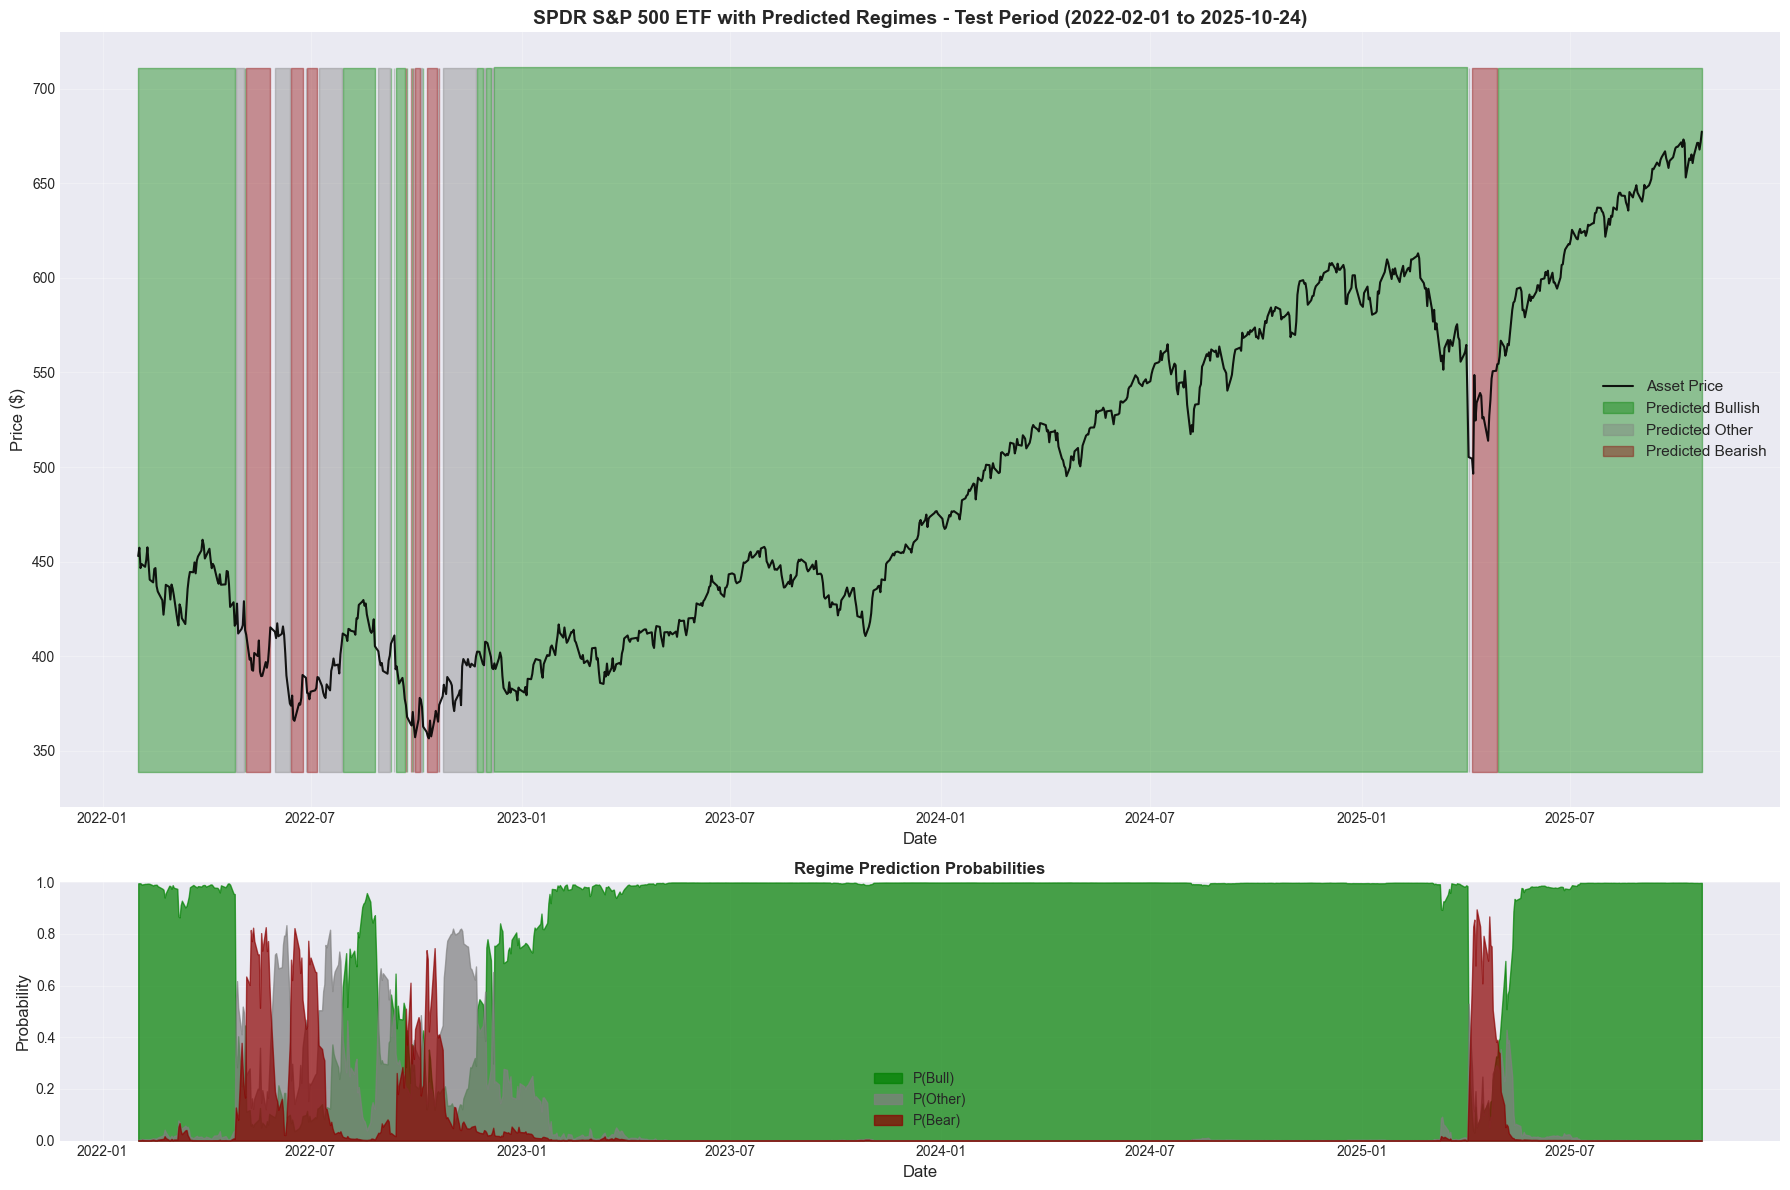

In [4]:
# Visualize predictions
print("\n" + "="*80)
print("VISUALIZING PREDICTIONS")
print("="*80)
model.viz_predictions(test_or_val=test_or_val_set)

## 4. Analyze Prediction Probabilities

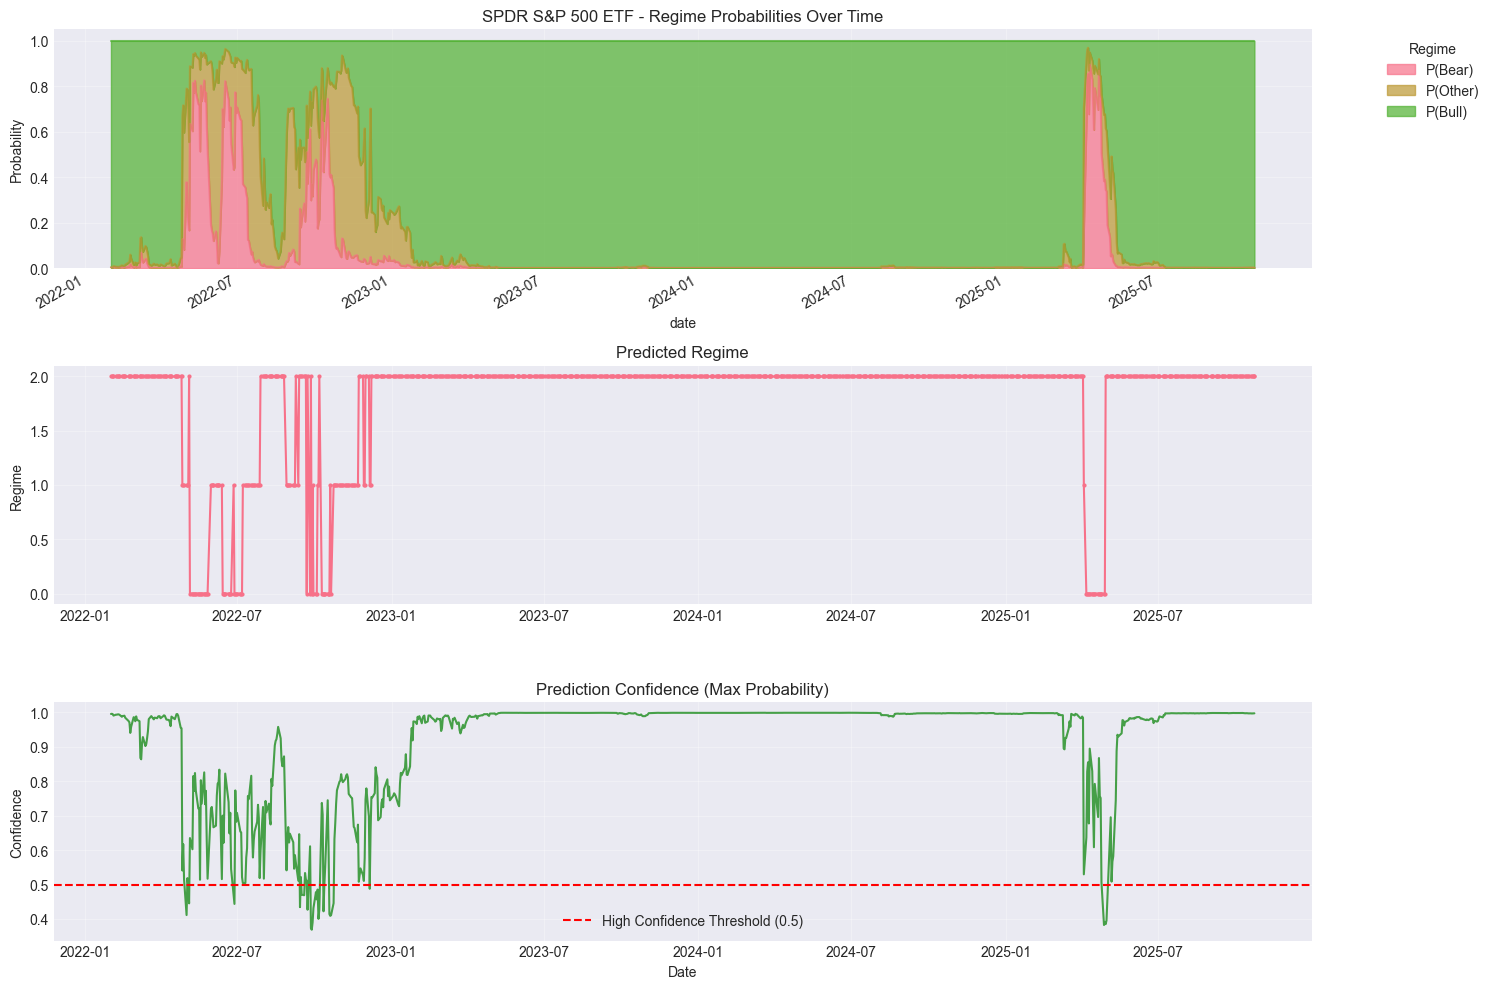


📊 Probability Statistics:
          P(Bear)    P(Other)     P(Bull)
count  937.000000  937.000000  937.000000
mean     0.058764    0.088880    0.852357
std      0.170928    0.186006    0.290829
min      0.000223    0.000390    0.030832
25%      0.000308    0.000869    0.953200
50%      0.000512    0.002370    0.996970
75%      0.006100    0.040959    0.998845
max      0.894952    0.833813    0.999302


In [5]:
# Extract regime probabilities and predicted regime
regime_probs = predictions.copy()
predicted_regime = predictions.apply(lambda row: row.argmax(), axis=1).rename('Predicted Regime')

# Visualize regime probabilities over time
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(15, 10))

# Plot 1: Regime probabilities stacked
regime_probs.plot(kind='area', stacked=True, ax=axes[0], alpha=0.7)
axes[0].set_title(f'{model.asset_name} - Regime Probabilities Over Time')
axes[0].set_ylabel('Probability')
axes[0].legend(title='Regime', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[0].grid(True, alpha=0.3)

# Plot 2: Predicted regime
predicted_regime_numeric = pd.Series(
    predicted_regime.map({regime: i for i, regime in enumerate(sorted(predicted_regime.unique()))}),
    index=predicted_regime.index
)
axes[1].plot(predicted_regime_numeric.index, predicted_regime_numeric.values, marker='.', markersize=4)
axes[1].set_title('Predicted Regime')
axes[1].set_ylabel('Regime')
axes[1].grid(True, alpha=0.3)

# Plot 3: Maximum probability (confidence)
max_proba = regime_probs.max(axis=1)
axes[2].plot(max_proba.index, max_proba.values, color='green', alpha=0.7)
axes[2].axhline(y=0.5, color='r', linestyle='--', label='High Confidence Threshold (0.5)')
axes[2].set_title('Prediction Confidence (Max Probability)')
axes[2].set_ylabel('Confidence')
axes[2].set_xlabel('Date')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n📊 Probability Statistics:")
print(regime_probs.describe())

## 5. Initialize and Test Trading Strategy with Default Parameters

In [6]:
# Load price data for the asset
price_data = model.raw_ohlc.droplevel(0, axis=1)
asset_prices = pd.DataFrame({
    'Open': price_data['open'],
    'Close': price_data['close']
})

# Align predictions with price data
aligned_predictions = predictions.reindex(asset_prices.index).dropna()
aligned_prices = asset_prices.reindex(aligned_predictions.index)

print(f"Asset: {model.asset_name}")
print(f"Predictions shape: {aligned_predictions.shape}")
print(f"Prices shape: {aligned_prices.shape}")
print(f"Price columns: {list(aligned_prices.columns)}")

Asset: SPDR S&P 500 ETF
Predictions shape: (937, 3)
Prices shape: (937, 2)
Price columns: ['Open', 'Close']


In [7]:
# Create strategy with default parameters
params = StrategyParameters()
params


StrategyParameters:
  stability_lookback: 42
  consistency_chnages_threshold: 10
  stability_threshold: 0.7
  min_prob_threshold: 0.4
  other_vol_window: 10
  Stability weights: consistency=0.3, concentration=0.3, other_level=0.1, other_volatility=0.3

In [8]:
strategy = RegimeTradingStrategy(aligned_predictions, aligned_prices, params)

# Run backtest
print("\n🔄 Running backtest with default parameters...")
results = strategy.backtest()

print("\n📈 Performance Summary:")
print(f"  Total Return: {results['total_return']:.2%}")
print(f"  Sharpe Ratio: {results['sharpe_ratio']:.3f}")
print(f"  Max Drawdown: {results['max_drawdown']:.2%}")
print(f"  Win Rate: {results['win_rate']:.2%}")
print(f"  Number of Trades: {results['num_trades']}")
print(f"  Average Trade: {results['avg_trade']:.2%}")

print("\n📈 Buy & Hold Comparison:")
print(f"  B&H Total Return: {results['buy_hold_total_return']:.2%}")
print(f"  B&H Sharpe Ratio: {results['buy_hold_sharpe']:.3f}")
print(f"  B&H Max Drawdown: {results['buy_hold_max_dd']:.2%}")


🔄 Running backtest with default parameters...

📈 Performance Summary:
  Total Return: 24.38%
  Sharpe Ratio: 0.330
  Max Drawdown: -31.27%
  Win Rate: 53.48%
  Number of Trades: 16
  Average Trade: 0.03%

📈 Buy & Hold Comparison:
  B&H Total Return: 49.52%
  B&H Sharpe Ratio: 0.625
  B&H Max Drawdown: -22.75%


## 6. Visualize Strategy Performance

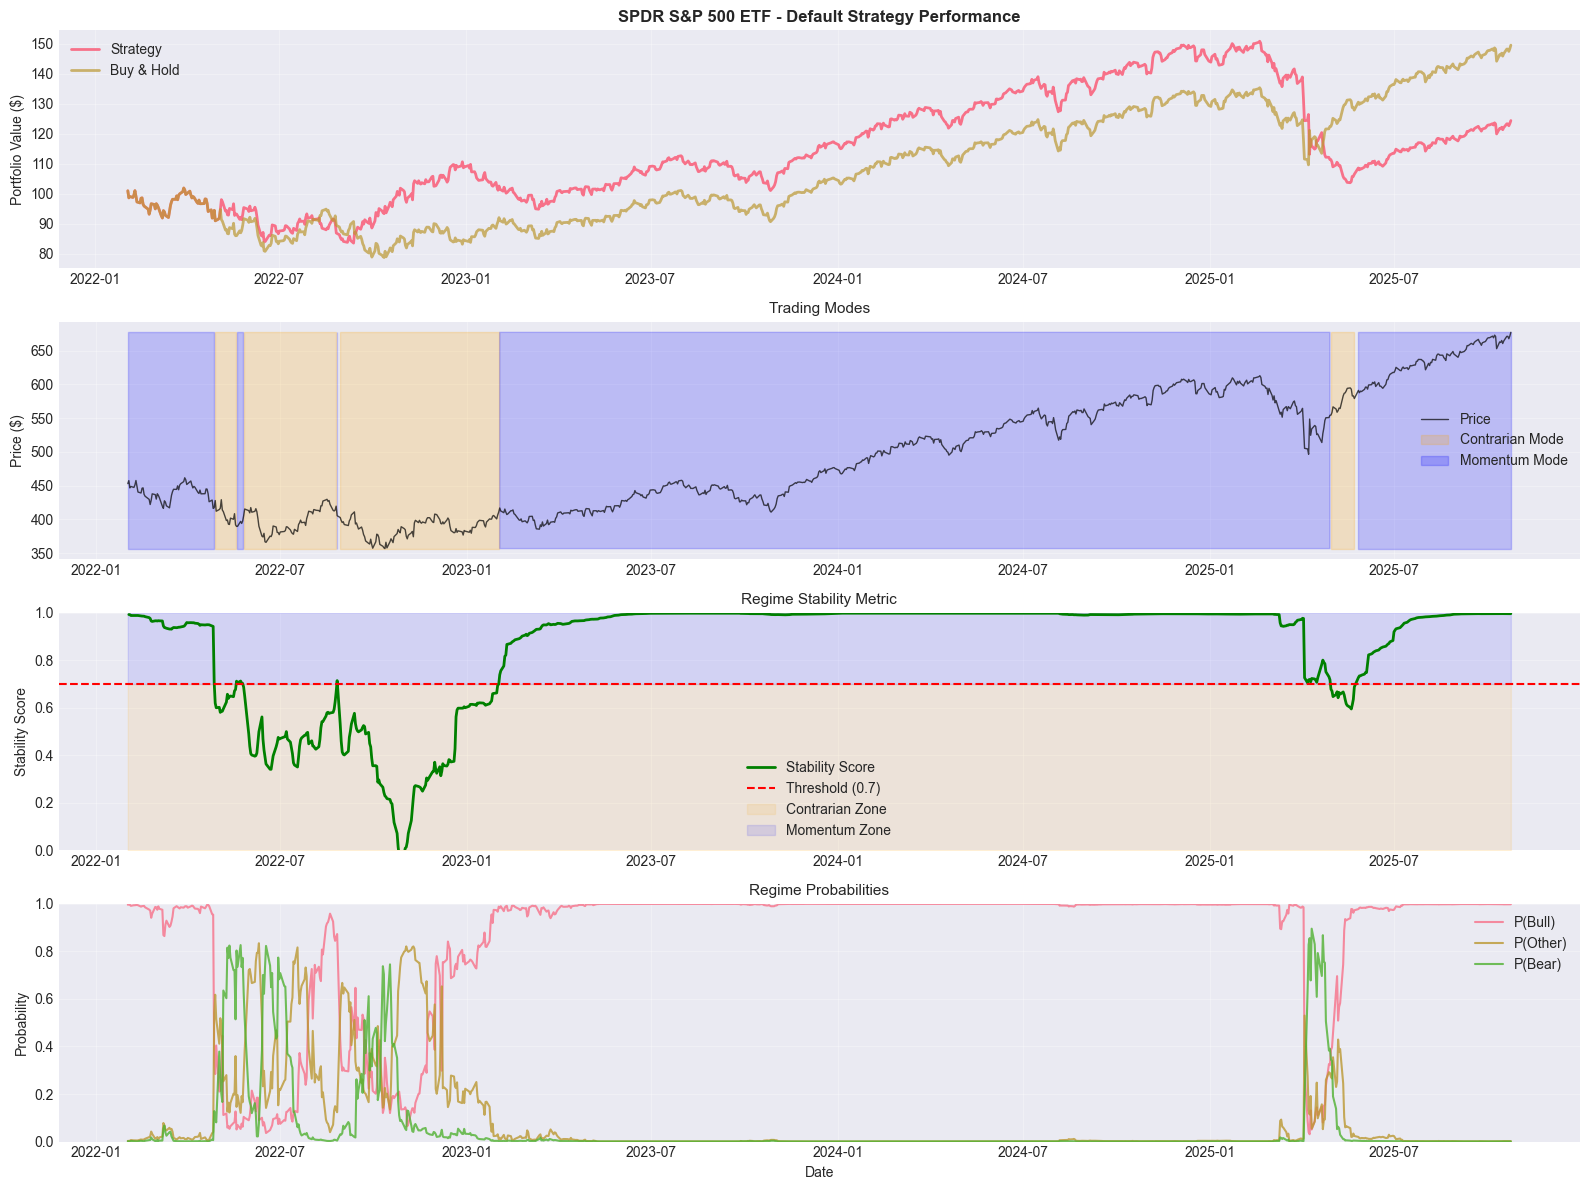

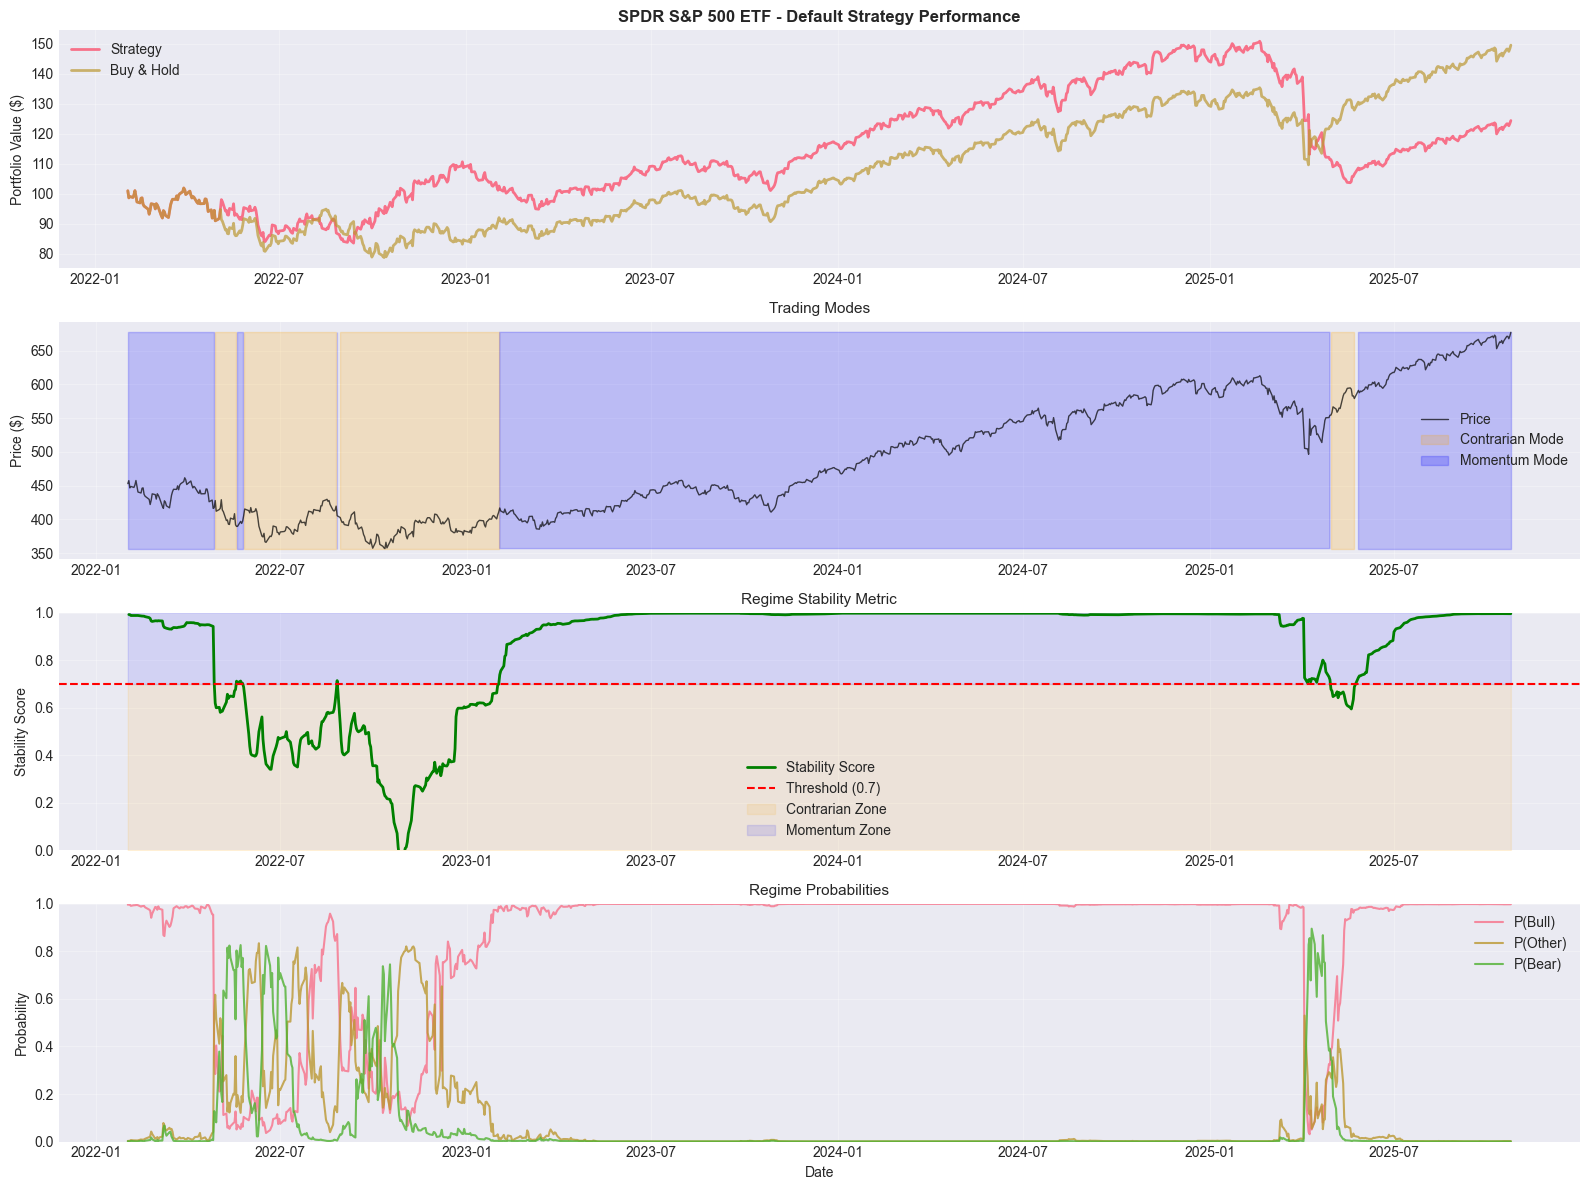

In [9]:
# Plot comprehensive performance visualization
strategy.plot_performance(f'{model.asset_name} - Default Strategy Performance')

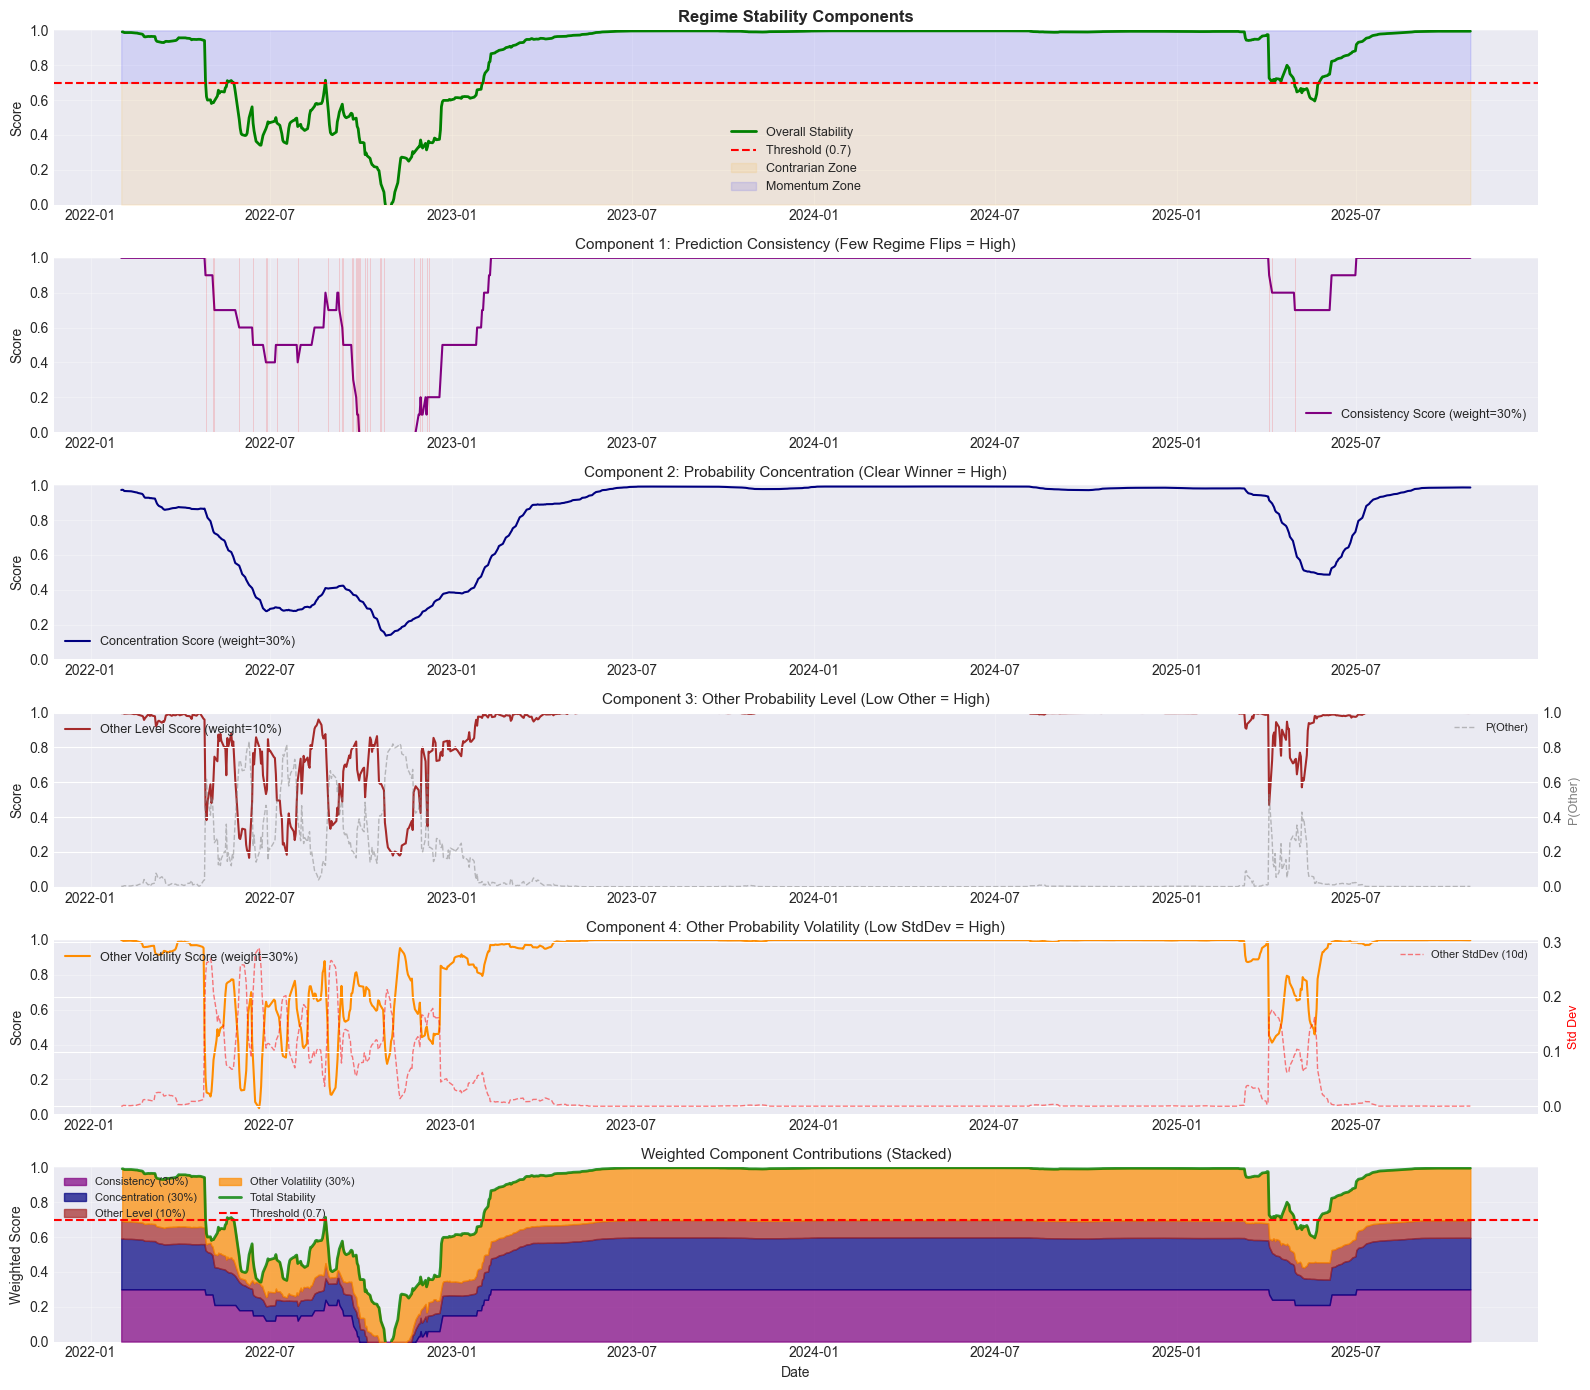

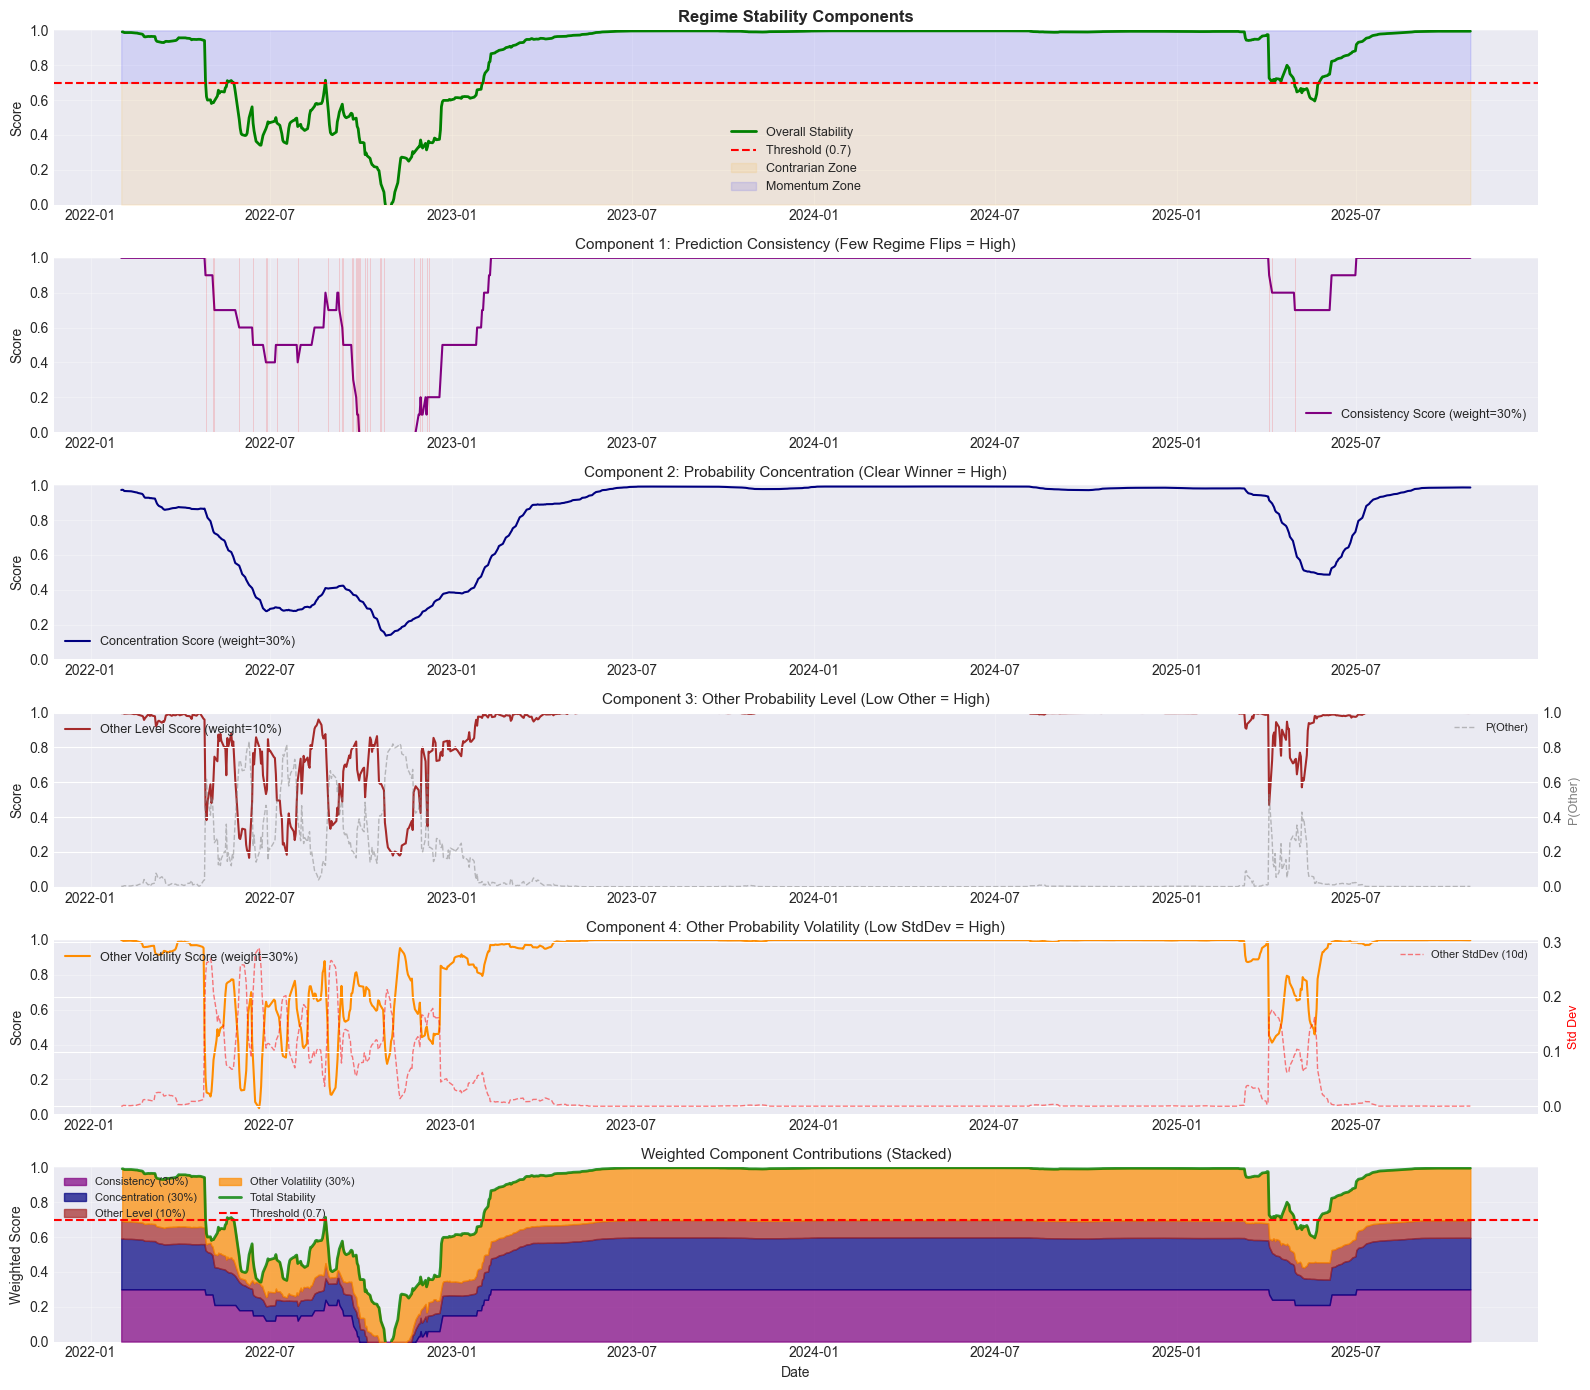

In [10]:
strategy.plot_stability_components()